In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.constants import mu_0, epsilon_0

from geoana import utils, spatial
from geoana.em import static

In [2]:
def decay_law(t, k, alpha, beta, gamma):

    return k * (t + alpha)**(-beta) * np.exp(-t / gamma)

In [3]:
t = np.logspace(-2, 2, 10)
alpha = 0.0191
beta = 1.01
gamma = 22.4
k = 1

L = decay_law(t, k, alpha, beta, gamma)

print(L)
print(t)

[3.55855924e+01 2.19450531e+01 1.05683313e+01 4.28447263e+00
 1.58148204e+00 5.47293450e-01 1.71740841e-01 4.23371910e-02
 5.39364018e-03 1.09926292e-04]
[1.00000000e-02 2.78255940e-02 7.74263683e-02 2.15443469e-01
 5.99484250e-01 1.66810054e+00 4.64158883e+00 1.29154967e+01
 3.59381366e+01 1.00000000e+02]


In [4]:
mu = mu_0  # permeability of free space (this is the default)
location = np.r_[0., 0., -10.]  # location of the dipole or pole

# dipole parameters
moment = 1
# inclination and declination (e.g. Vancouver)
inclination, declination = 67., 0.

In [5]:
def id_to_cartesian(inclination, declination):
    ux = np.cos(inclination/180.*np.pi)*np.sin(declination/180.*np.pi)
    uy = np.cos(inclination/180.*np.pi)*np.cos(declination/180.*np.pi)
    uz = -np.sin(inclination/180.*np.pi)
    return np.r_[ux, uy, uz]

orientation = id_to_cartesian(inclination, declination)

dipole = static.MagneticDipoleWholeSpace(
    location=location,
    orientation=orientation,
    moment=moment
)

pole = static.MagneticPoleWholeSpace(
    location=location,
    orientation=orientation,
    moment=moment
)

In [6]:
x = np.linspace(-36, 36, 100)
y = np.linspace(-36, 36, 100)
xyz = utils.ndgrid([x, y, np.r_[1.]])
 

b_vec_dipole = dipole.magnetic_flux_density(xyz)
b_vec_pole = pole.magnetic_flux_density(xyz)
b_total_dipole = dipole.dot_orientation(b_vec_dipole)
b_total_pole = pole.dot_orientation(b_vec_pole)

In [7]:
def plot_amplitude(ax, v):
    plt.colorbar(
        ax.pcolormesh(
            x, y, v.reshape(len(x), len(y), order='F')
        ), ax=ax
    )
    ax.axis('square')
    ax.set_xlabel('y (east,  m)')
    ax.set_ylabel('x (north,  m)')

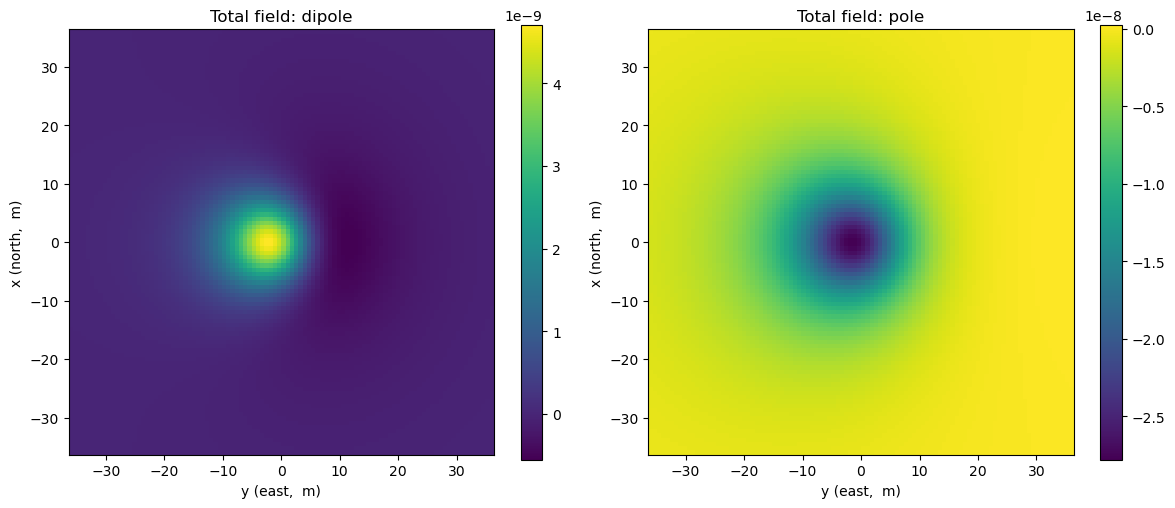

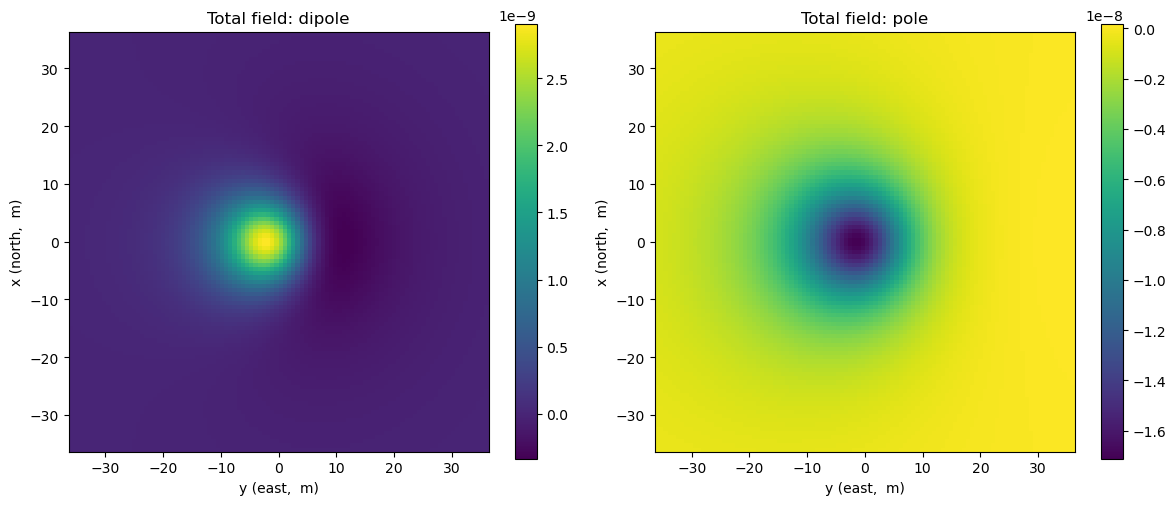

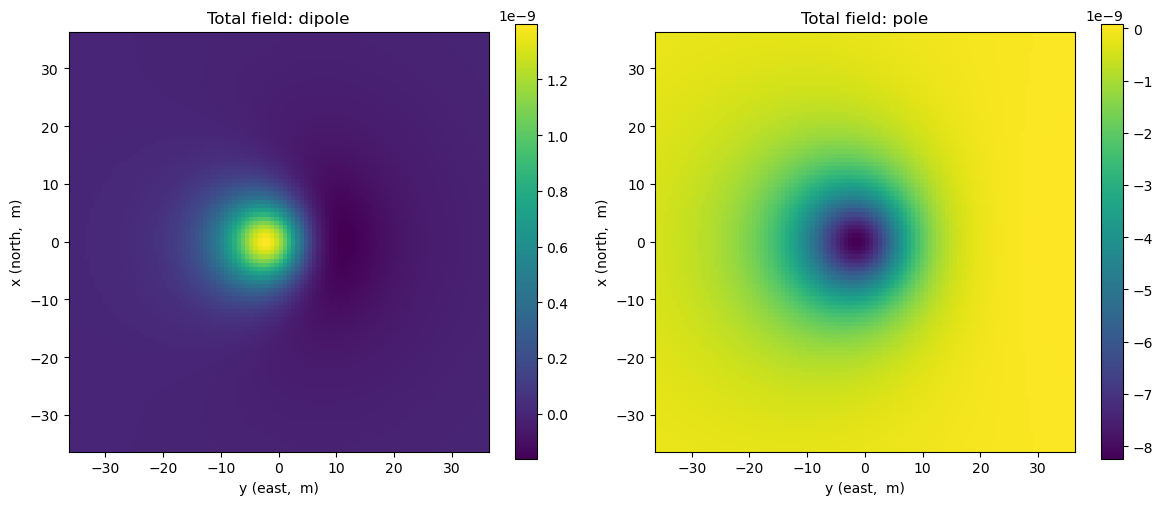

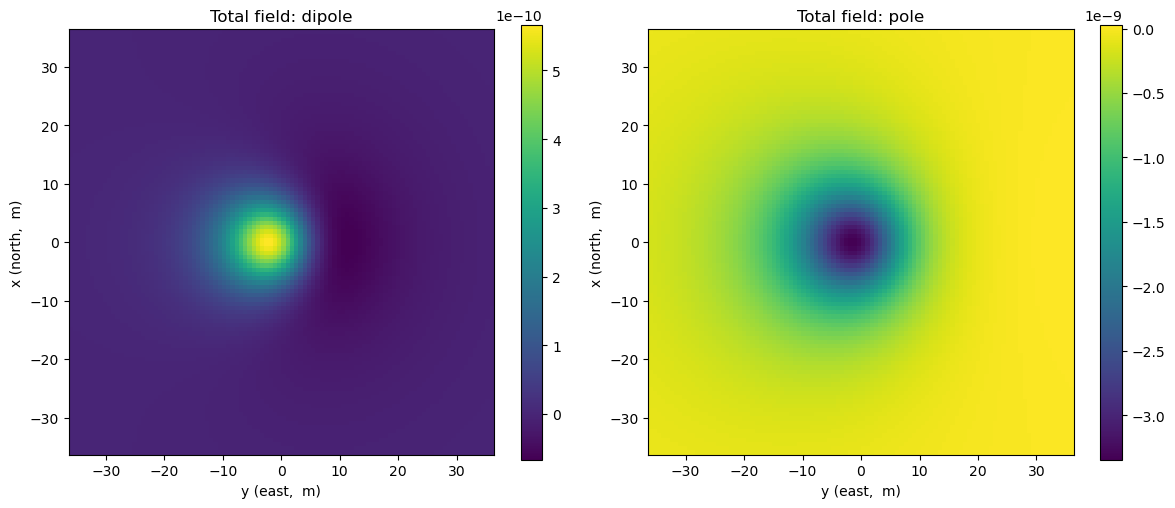

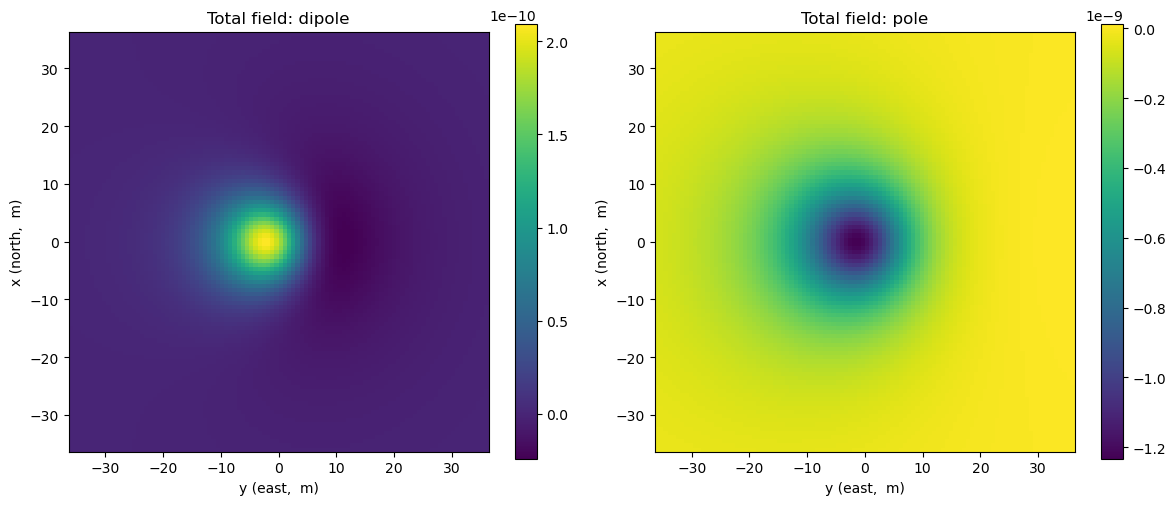

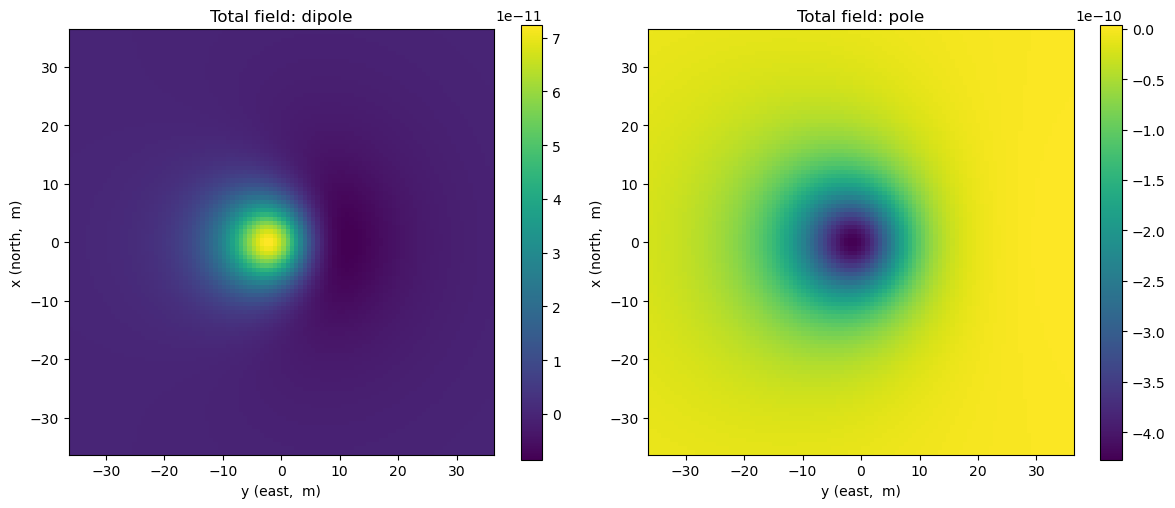

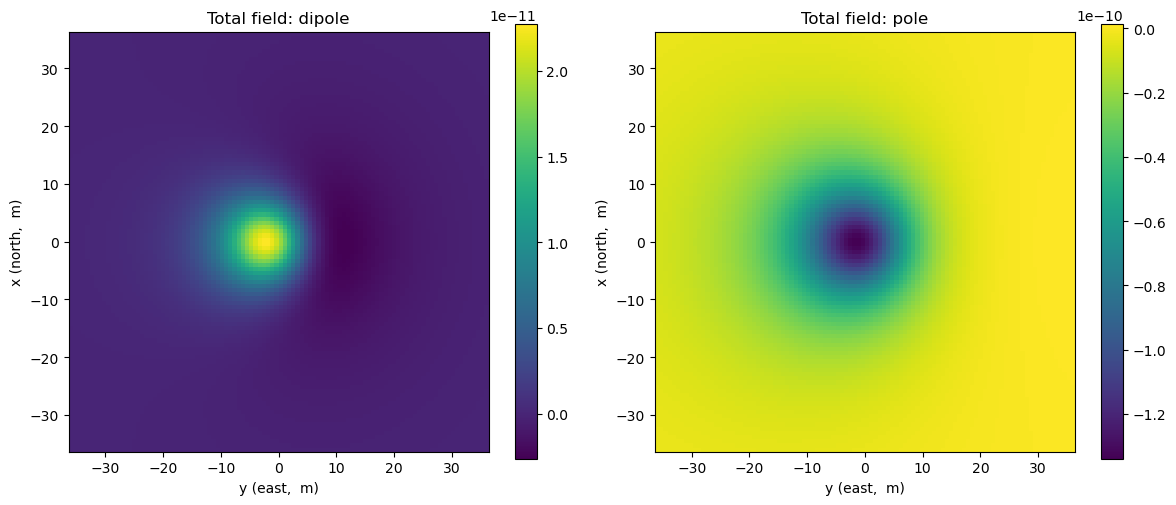

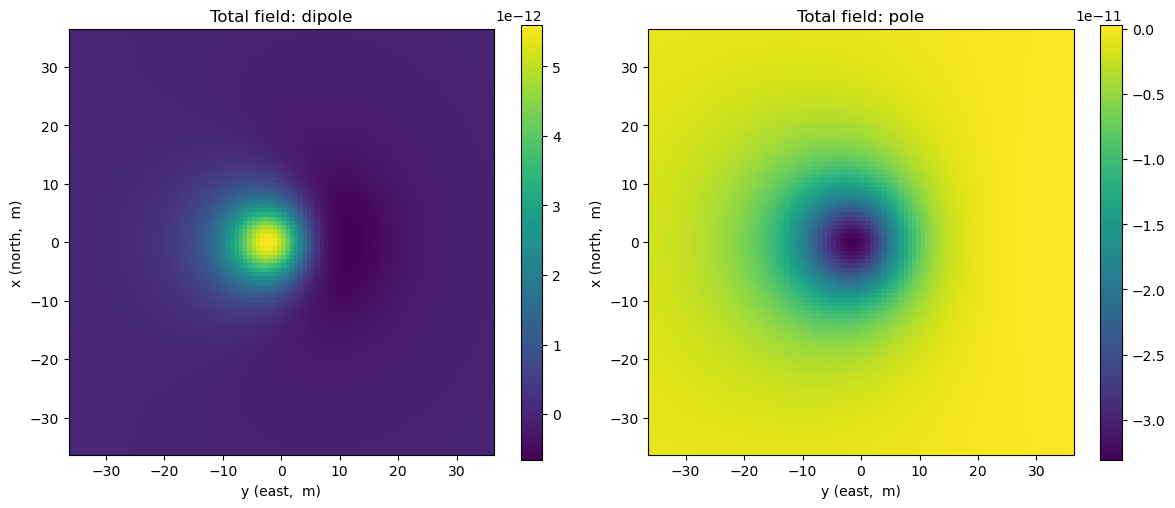

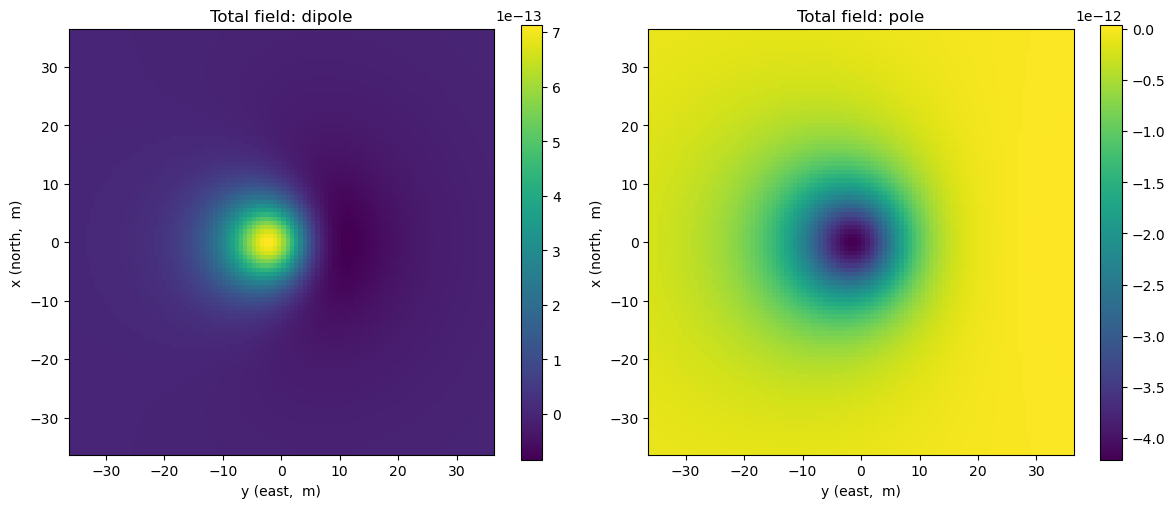

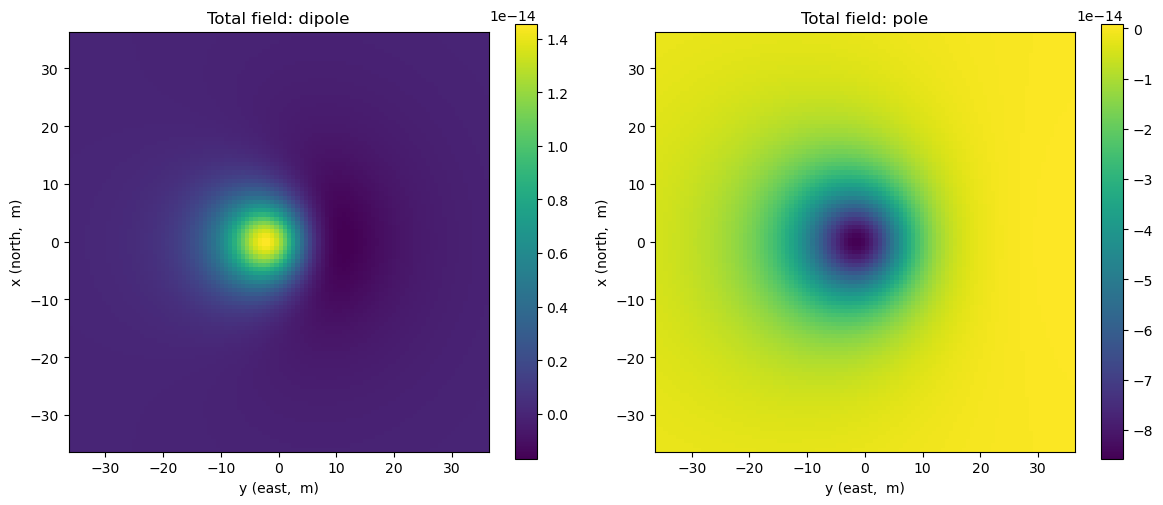

In [8]:
for val in L:
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    b_vec_dipole = val * dipole.magnetic_flux_density(xyz)
    b_vec_pole = val * pole.magnetic_flux_density(xyz)
    b_total_dipole = dipole.dot_orientation(b_vec_dipole)
    b_total_pole = pole.dot_orientation(b_vec_pole)
    
    # plot dipole vector potential
    plot_amplitude(ax[0], b_total_dipole)
    
    # plot loop vector potential
    plot_amplitude(ax[1], b_total_pole)
    
    
    # set the titles
    ax[0].set_title('Total field: dipole')
    ax[1].set_title('Total field: pole')
    
    # format so text doesn't overlap
    plt.tight_layout()
    plt.show()

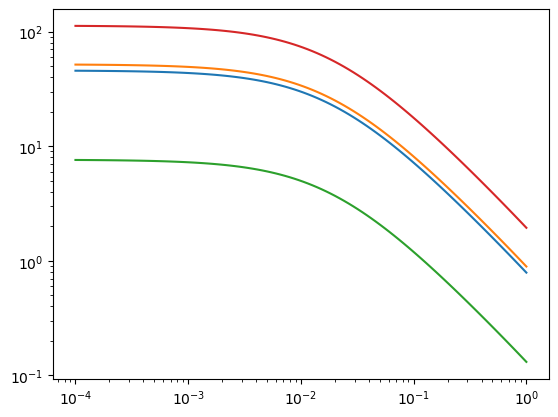

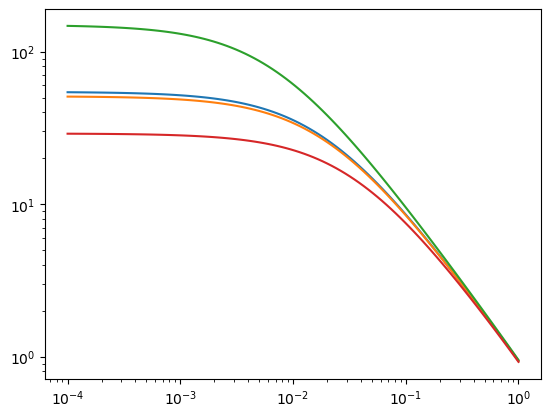

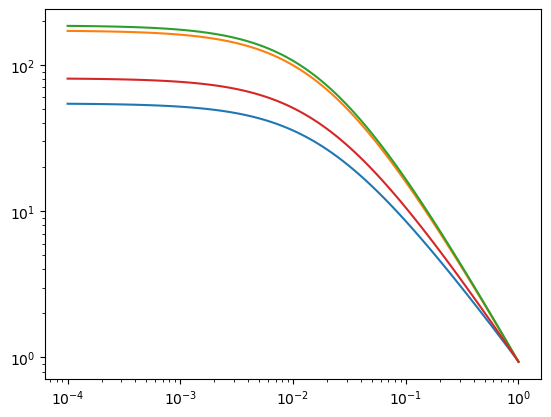

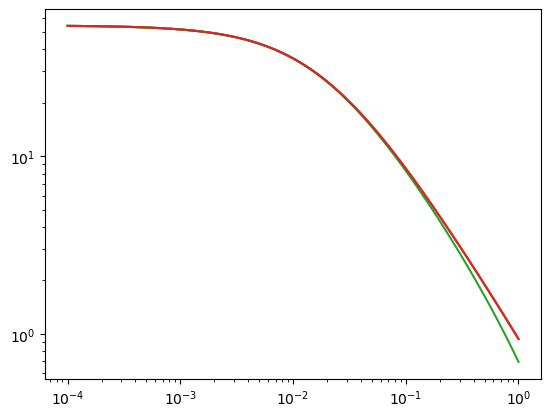

In [9]:
t = np.logspace(-4, 0, 100)

alpha = 0.0191
beta = 1.01
gamma = 22.4
k = 1

k_vals = [0.841,0.951,0.140,2.07]
alpha_vals = [0.0191,0.0204,0.00702, 0.0356]
beta_vals = [1.01,1.30,1.32,1.11]
gamma_vals = [22.4,22.6,2.92, 22.2]

for val in k_vals:
    L = decay_law(t, val, alpha, beta, gamma)
    plt.loglog(t, L)
plt.show()
for val in alpha_vals:
    L = decay_law(t, k, val, beta, gamma)
    plt.loglog(t, L)
plt.show()
for val in beta_vals:
    L = decay_law(t, k, alpha, val, gamma)
    plt.loglog(t, L)
plt.show()
for val in gamma_vals:
    L = decay_law(t, k, alpha, beta, val)
    plt.loglog(t, L)
plt.show()

In [10]:
def decay_law(t, k, alpha, beta, gamma):
    return k * (t + alpha)**(-beta) * np.exp(-t / gamma)


def magnetic_sphere_em(x, y, z_obs,
                       x0, y0, z0,
                       a,
                       Bp,
                       t,
                       k, alpha, beta, gamma):
    
    # Geometry
    dx = x - x0
    dy = y - y0
    dz = z_obs - z0
    
    R = np.sqrt(dx**2 + dy**2 + dz**2)
    R[R == 0] = 1e-10
    
    cos_theta = dz / R
    sin_theta = np.sqrt(dx**2 + dy**2) / R
    
    # Your decay law
    L = decay_law(t, k, alpha, beta, gamma)
    
    # Spherical components (from your equation)
    B_r = Bp * (a**3 / R**3) * cos_theta * L
    B_theta = Bp * (a**3 / (2 * R**3)) * sin_theta * L
    
    # Convert to vertical component
    Bz = B_r * cos_theta - B_theta * sin_theta
    
    return Bz

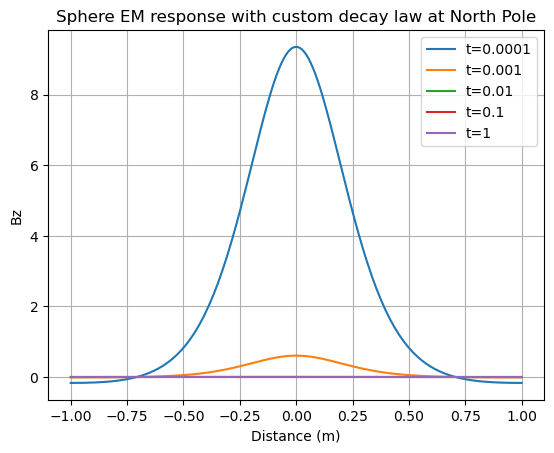

In [11]:
x = np.linspace(-1, 1, 200)
y = np.zeros_like(x)

# Parameters
params = dict(
    x0=0, y0=0, z0=-0.5,
    a=0.015,
    Bp=1,
    k=1,
    alpha=1e-4,
    beta=1.5,
    gamma=0.005
)

plt.figure()

for ti in [1e-4, 1e-3, 1e-2, 1e-1,1]:
    dBz = magnetic_sphere_em(
        x, y, 0,
        t=ti,
        **params
    )
    plt.plot(x, dBz, label=f't={ti}')

plt.legend()
plt.xlabel('Distance (m)')
plt.ylabel('Bz')
plt.title('Sphere EM response with custom decay law at North Pole')
plt.grid()
plt.show()

# Grid
x_grid = np.linspace(-36, 36, 100)
y_grid = np.linspace(-36, 36, 100)
xyz = utils.ndgrid([x_grid, y_grid, np.r_[1.]])

print('xyz shape:', xyz.shape)
print('x range:', xyz[:,0].min(), xyz[:,0].max())
print('y range:', xyz[:,1].min(), xyz[:,1].max())

# Plot function using x_grid/y_grid
def plot_amplitude_sym(ax, v, title=''):
    vmax = np.abs(v).max()
    if vmax == 0: vmax = 1
    im = ax.pcolormesh(
        x_grid, y_grid, v.reshape(len(x_grid), len(y_grid), order='F'),
        cmap='RdBu_r', vmin=-vmax, vmax=vmax
    )
    plt.colorbar(im, ax=ax)
    ax.axis('square')
    ax.set_xlabel('y (east, m)')
    ax.set_ylabel('x (north, m)')
    ax.set_title(title)

# Decay parameters
t = np.logspace(-4, 0, 100)
k1, alpha1, beta1, gamma1 = 0.841, 0.0191, 1.01, 22.4
k2, alpha2, beta2, gamma2 = 0.140, 0.00702, 1.32, 2.92
k3, alpha3, beta3, gamma3 = 0.140, 0.00702, 1.32, 2.92

# Orientations
# Earth's field direction (fixed - Vancouver)
inclination_earth, declination_earth = 67., 0.
earth_hat = id_to_cartesian(inclination_earth, declination_earth)

# UXO long axis orientation (different from Earth's field)
inclination_uxo, declination_uxo = 30., 45. # tilted and rotated
long_axis = id_to_cartesian(inclination_uxo, declination_uxo)

#gram_schmidt
arbitrary = np.r_[0., 0., 1.] if abs(long_axis[2]) < 0.9 else np.r_[1., 0., 0.]
cross1 = np.cross(long_axis, arbitrary); cross1 /= np.linalg.norm(cross1)
cross2 = np.cross(long_axis, cross1);    cross2 /= np.linalg.norm(cross2)

print('Long axis :', long_axis)
print('Cross axis 1:', cross1)
print('Cross axis 2:', cross2)
print('Dot products (should all be 0ish):', long_axis @ cross1, long_axis @ cross2, cross1 @ cross2)

# Dipoles
location = np.r_[0., 0., -10.]
dipole_long   = static.MagneticDipoleWholeSpace(location=location, orientation=long_axis, moment=1)
dipole_cross1 = static.MagneticDipoleWholeSpace(location=location, orientation=cross1,    moment=1)
dipole_cross2 = static.MagneticDipoleWholeSpace(location=location, orientation=cross2,    moment=1)

for ti in t_plot:
    L1_t = decay_law(ti, k1, alpha1, beta1, gamma1)
    L2_t = decay_law(ti, k2, alpha2, beta2, gamma2)
    L3_t = decay_law(ti, k3, alpha3, beta3, gamma3)

    b_long = L1_t * dipole_long.magnetic_flux_density(xyz)
    b_cross1 = L2_t * dipole_cross1.magnetic_flux_density(xyz)
    b_cross2 = L3_t * dipole_cross2.magnetic_flux_density(xyz)

    b_total_vec = b_long + b_cross1 + b_cross2

    # Project ALL fields onto the same fixed Earth-field direction
    total = b_total_vec @ earth_hat
    long_only = b_long @ earth_hat

    print(f't={ti:.2e}  total range: {total.min():.3e} to {total.max():.3e}')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    plot_amplitude_sym(axes[0], total, f'UXO total field (t={ti:.2e} s)')
    plot_amplitude_sym(axes[1], long_only, f'Long-axis only (t={ti:.2e} s)')
    plt.tight_layout()
    plt.show()


long axis doesnt decay???? Tried again with different amplitude allowance and things actually decayed but really fast so look below its pretty good in my opinion

xyz shape: (10000, 3)
x range: -36.0 36.0
y range: -36.0 36.0
Long axis   : [ 0.61237244  0.61237244 -0.5       ]
Cross axis 1: [ 0.70710678 -0.70710678  0.        ]
Cross axis 2: [-0.35355339 -0.35355339 -0.8660254 ]
Dot products (should all be 0ish): 0.0 5.551115123125783e-17 0.0
t=1.00e-03  total range: -1.397e-09 to 1.535e-08


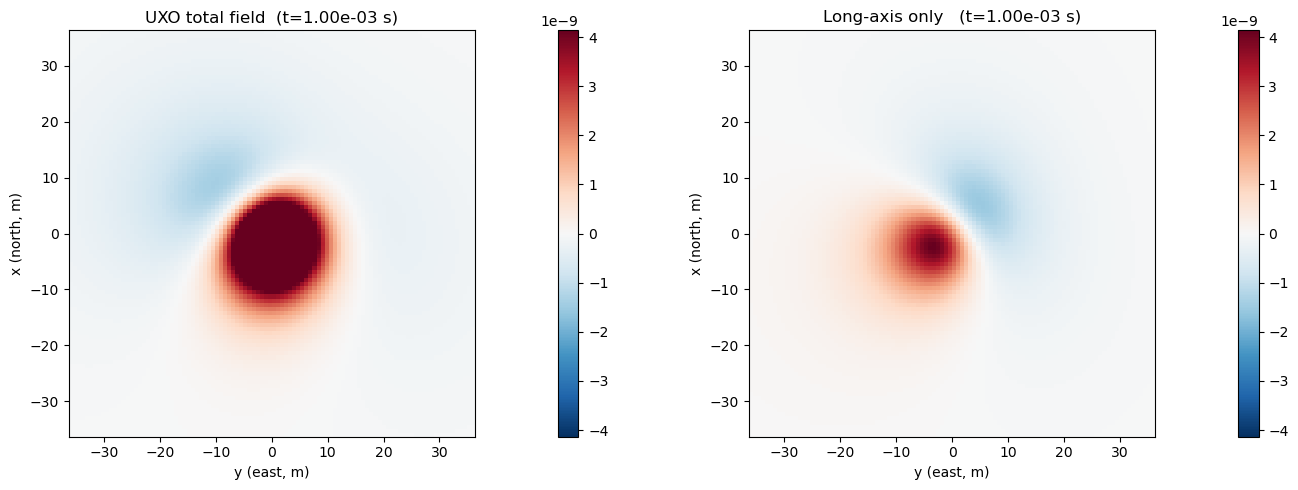

t=1.52e-03  total range: -1.279e-09 to 1.426e-08


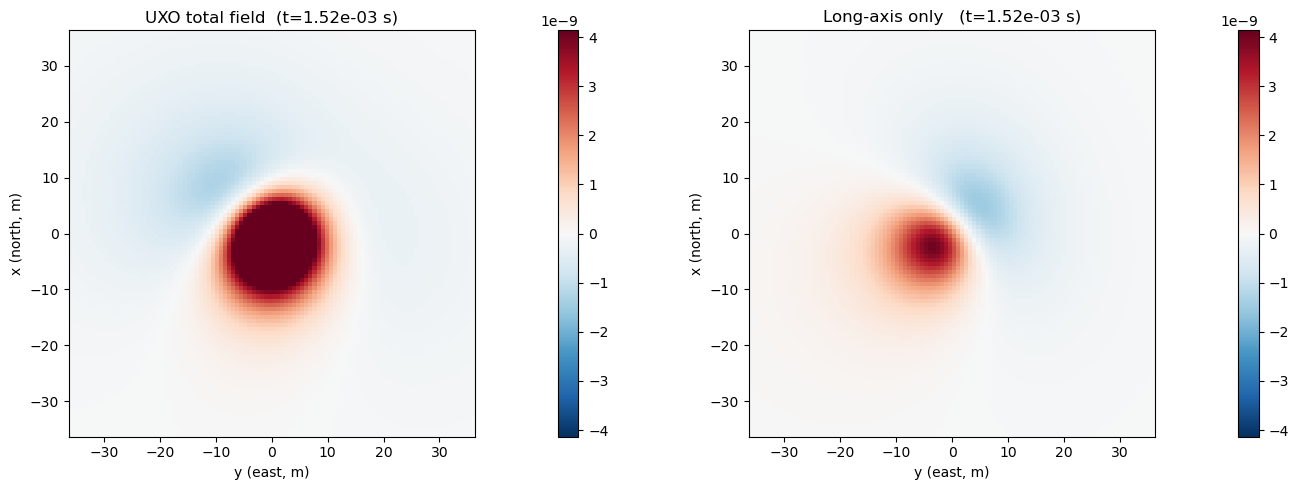

t=2.31e-03  total range: -1.136e-09 to 1.287e-08


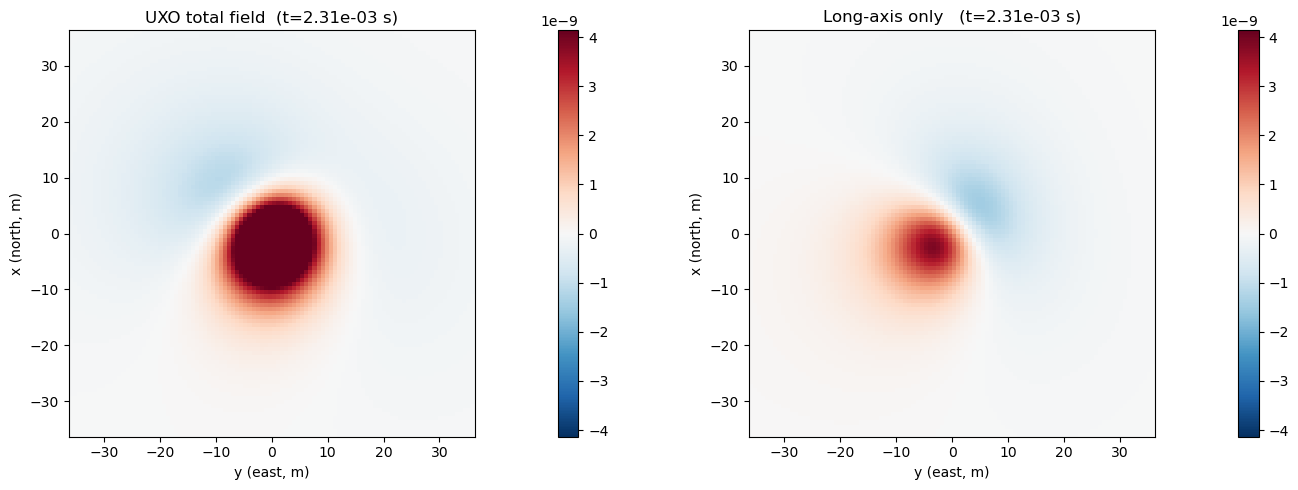

t=3.51e-03  total range: -9.701e-10 to 1.119e-08


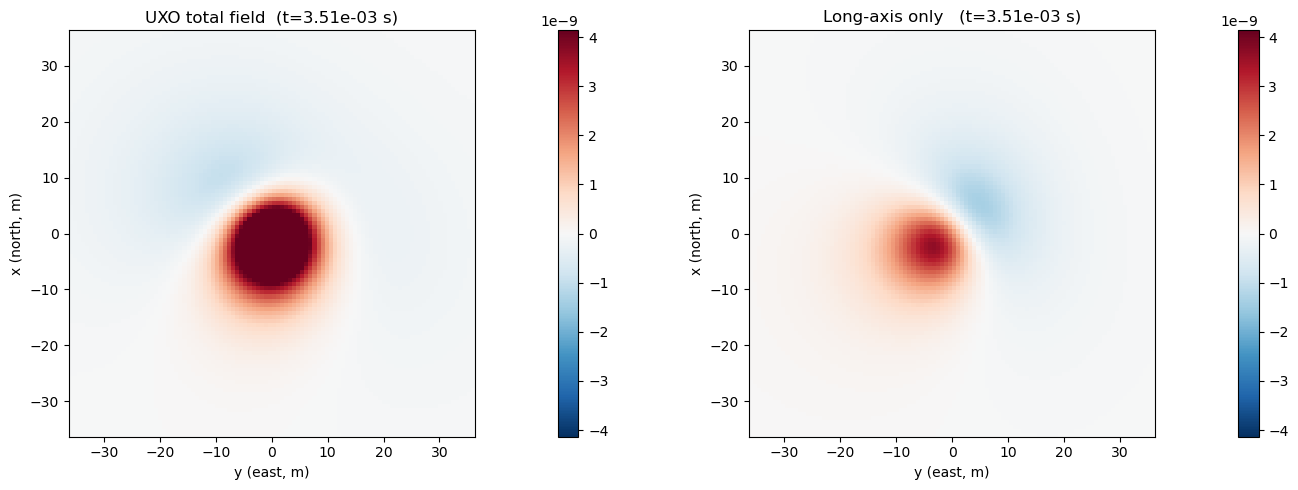

t=5.34e-03  total range: -7.982e-10 to 9.330e-09


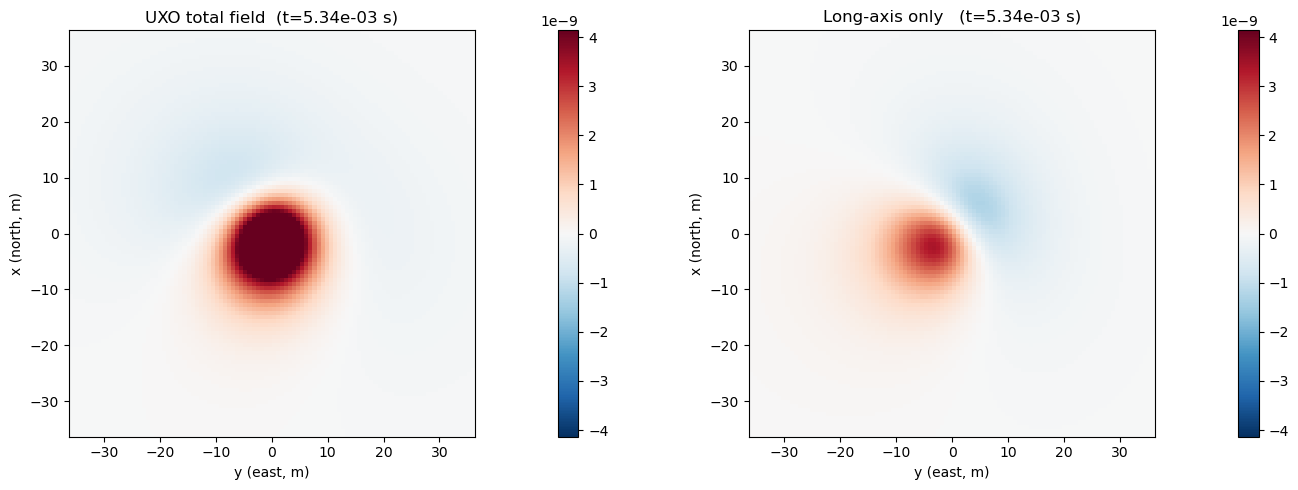

t=8.11e-03  total range: -6.399e-10 to 7.472e-09


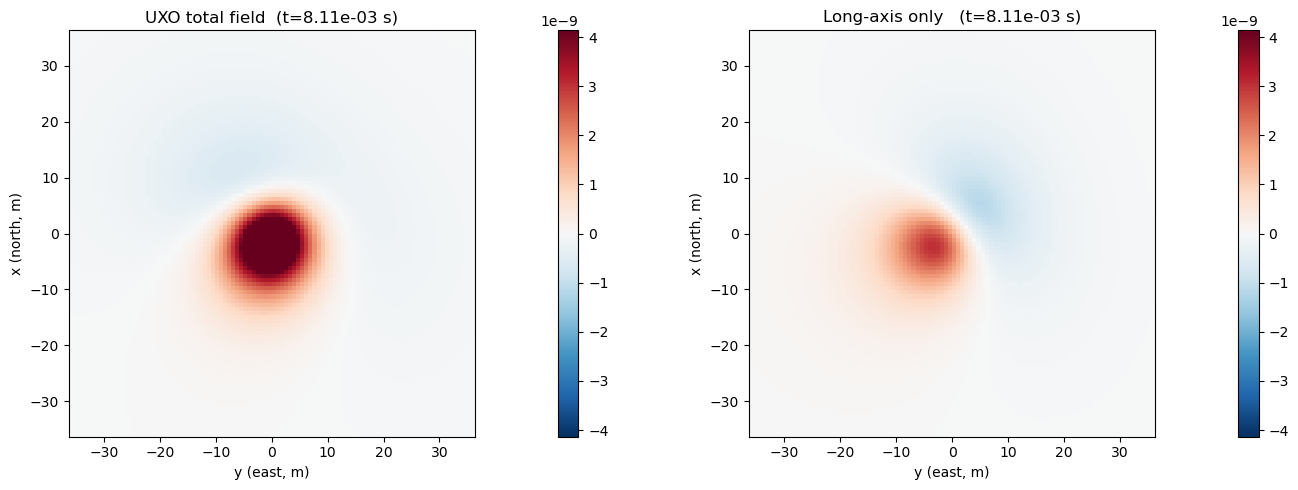

t=1.23e-02  total range: -5.083e-10 to 5.720e-09


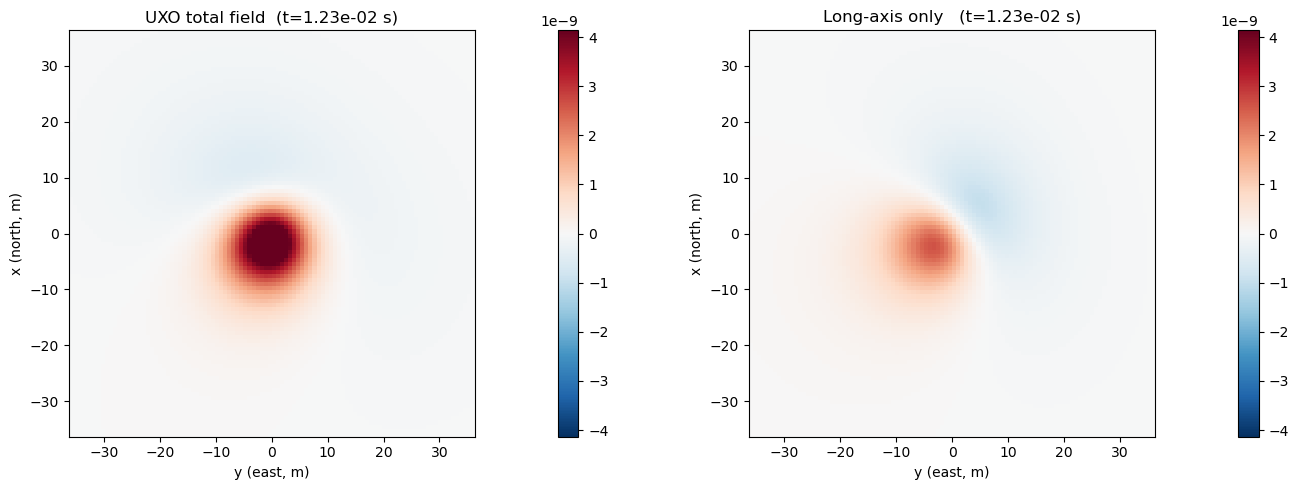

t=1.87e-02  total range: -4.060e-10 to 4.199e-09


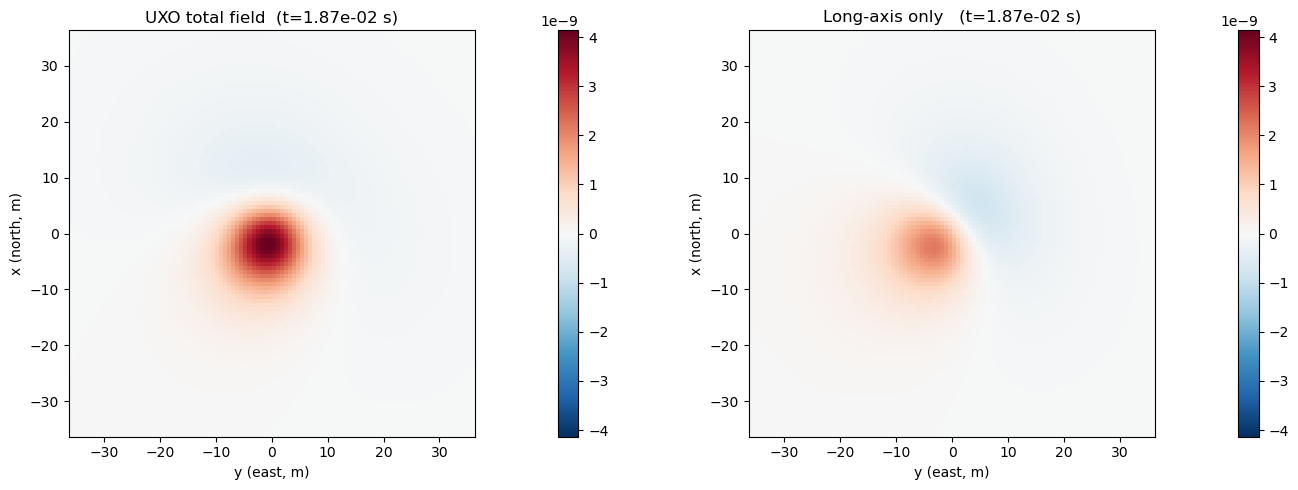

t=2.85e-02  total range: -3.257e-10 to 3.000e-09


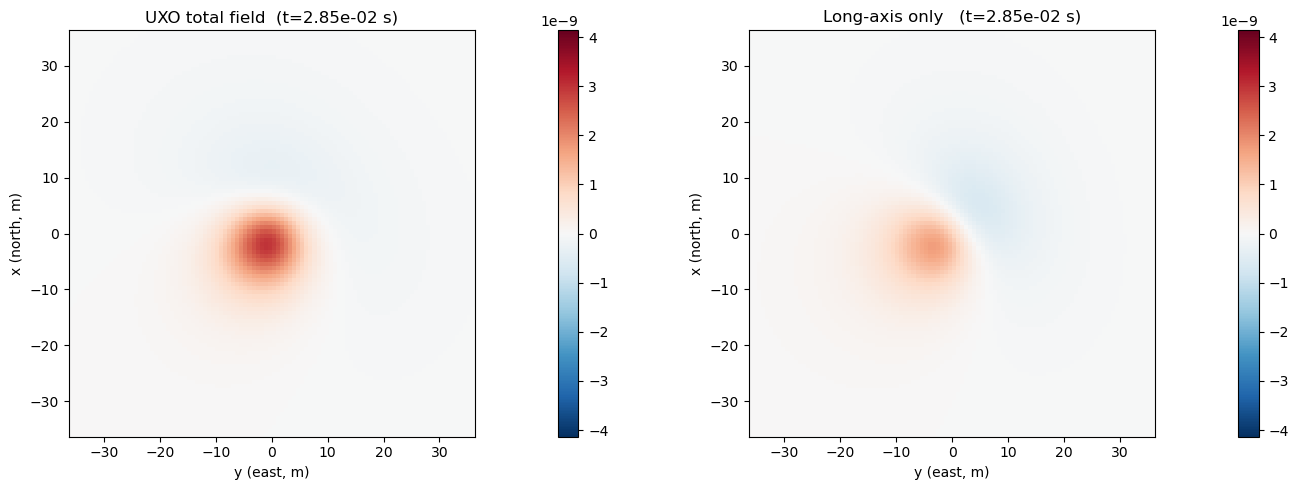

t=4.33e-02  total range: -2.592e-10 to 2.079e-09


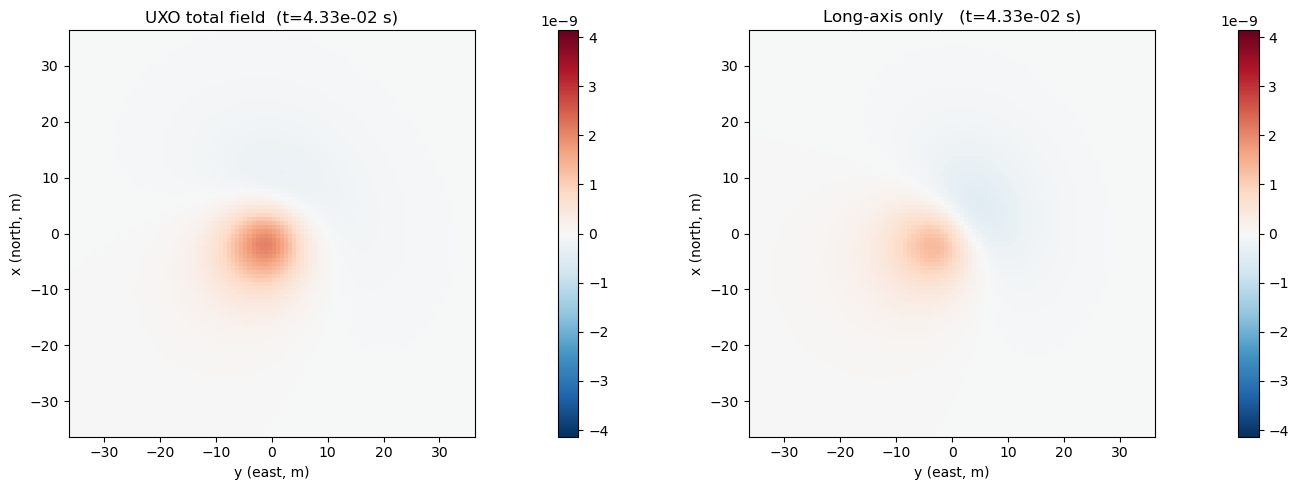

t=6.58e-02  total range: -2.015e-10 to 1.409e-09


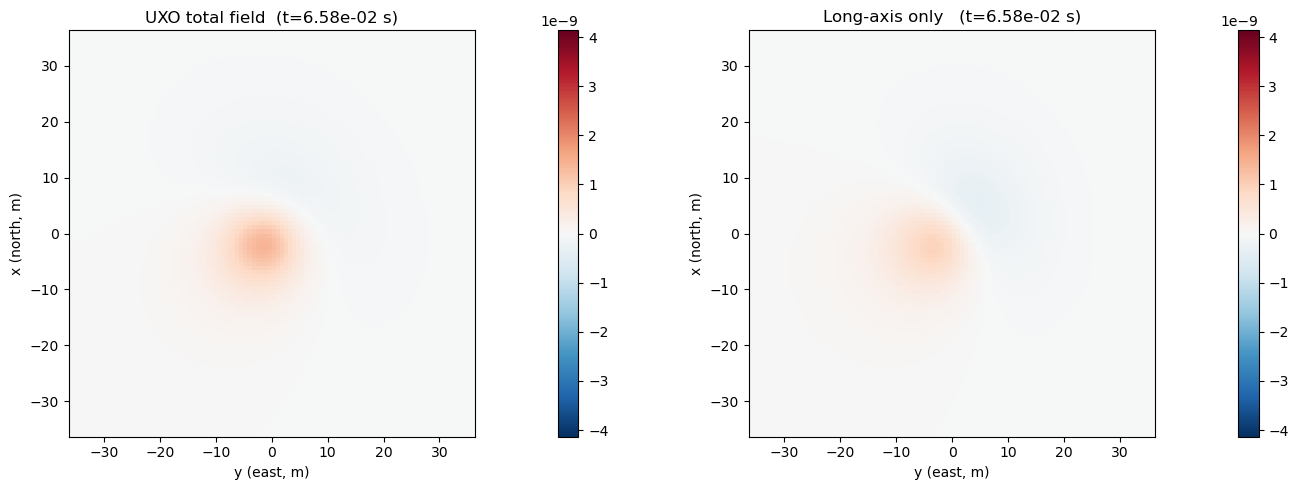

t=1.00e-01  total range: -1.524e-10 to 9.398e-10


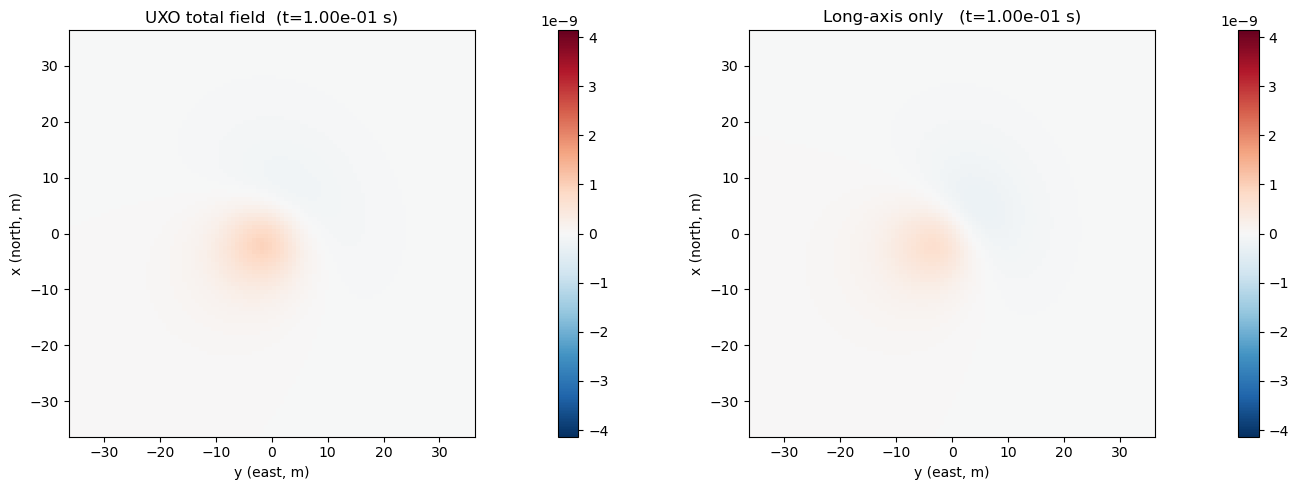

In [34]:
# Grid
x_grid = np.linspace(-36, 36, 100)
y_grid = np.linspace(-36, 36, 100)
xyz = utils.ndgrid([x_grid, y_grid, np.r_[1.]])
print('xyz shape:', xyz.shape)
print('x range:', xyz[:,0].min(), xyz[:,0].max())
print('y range:', xyz[:,1].min(), xyz[:,1].max())

# Plot function with optional fixed vmax
def plot_amplitude_sym(ax, v, title='', vmax=None):
    if vmax is None:
        vmax = np.abs(v).max()
    if vmax == 0: vmax = 1
    im = ax.pcolormesh(
        x_grid, y_grid, v.reshape(len(x_grid), len(y_grid), order='F'),
        cmap='RdBu_r', vmin=-vmax, vmax=vmax
    )
    plt.colorbar(im, ax=ax)
    ax.axis('square')
    ax.set_xlabel('y (east, m)')
    ax.set_ylabel('x (north, m)')
    ax.set_title(title)

# Decay parameters
t = np.logspace(-4, 0, 100)
k1, alpha1, beta1, gamma1 = 0.841, 0.0191, 1.01, 22.4
k2, alpha2, beta2, gamma2 = 0.140, 0.00702, 1.32, 2.92
k3, alpha3, beta3, gamma3 = 0.140, 0.00702, 1.32, 2.92

# Earth's field direction (fixed - Vancouver)
inclination_earth, declination_earth = 67., 0.
earth_hat = id_to_cartesian(inclination_earth, declination_earth)

# UXO long axis orientation (just made it different so plots would show up not the same thing)
inclination_uxo, declination_uxo = 30., 45.
long_axis = id_to_cartesian(inclination_uxo, declination_uxo)

# Gram-Schmidt cross axes (don't ask where i got this from)
arbitrary = np.r_[0., 0., 1.] if abs(long_axis[2]) < 0.9 else np.r_[1., 0., 0.]
cross1 = np.cross(long_axis, arbitrary); cross1 /= np.linalg.norm(cross1)
cross2 = np.cross(long_axis, cross1);    cross2 /= np.linalg.norm(cross2)

print('Long axis   :', long_axis)
print('Cross axis 1:', cross1)
print('Cross axis 2:', cross2)
print('Dot products (should all be 0ish):', long_axis @ cross1, long_axis @ cross2, cross1 @ cross2)

# Dipoles
location = np.r_[0., 0., -10.]
dipole_long   = static.MagneticDipoleWholeSpace(location=location, orientation=long_axis, moment=1)
dipole_cross1 = static.MagneticDipoleWholeSpace(location=location, orientation=cross1,    moment=1)
dipole_cross2 = static.MagneticDipoleWholeSpace(location=location, orientation=cross2,    moment=1)

# Calculate global color scale from the first time step
t_plot = np.logspace(-3, -1, 12) #thought this time looked the best.
L1_first = decay_law(t_plot[0], k1, alpha1, beta1, gamma1)
b_long_first = L1_first * dipole_long.magnetic_flux_density(xyz)
global_vmax = np.abs(b_long_first @ earth_hat).max()

#loop over time gates
for ti in t_plot:
    L1_t = decay_law(ti, k1, alpha1, beta1, gamma1)
    L2_t = decay_law(ti, k2, alpha2, beta2, gamma2)
    L3_t = decay_law(ti, k3, alpha3, beta3, gamma3)

    b_long   = L1_t * dipole_long.magnetic_flux_density(xyz)
    b_cross1 = L2_t * dipole_cross1.magnetic_flux_density(xyz)
    b_cross2 = L3_t * dipole_cross2.magnetic_flux_density(xyz)

    b_total_vec = b_long + b_cross1 + b_cross2

    total = b_total_vec @ earth_hat
    long_only = b_long @ earth_hat

    print(f't={ti:.2e}  total range: {total.min():.3e} to {total.max():.3e}')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    plot_amplitude_sym(axes[0], total,f'UXO total field  (t={ti:.2e} s)', vmax=global_vmax)
    plot_amplitude_sym(axes[1], long_only,f'Long-axis only   (t={ti:.2e} s)', vmax=global_vmax)
    plt.tight_layout()
    plt.show()